Experiment 5: Advanced Convolutional Neural Networks

Aim:To implement an advanced Convolutional Neural Network (CNN) using TensorFlow and Keras with Dropout layers for improved image classification performance.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 447s 3us/step


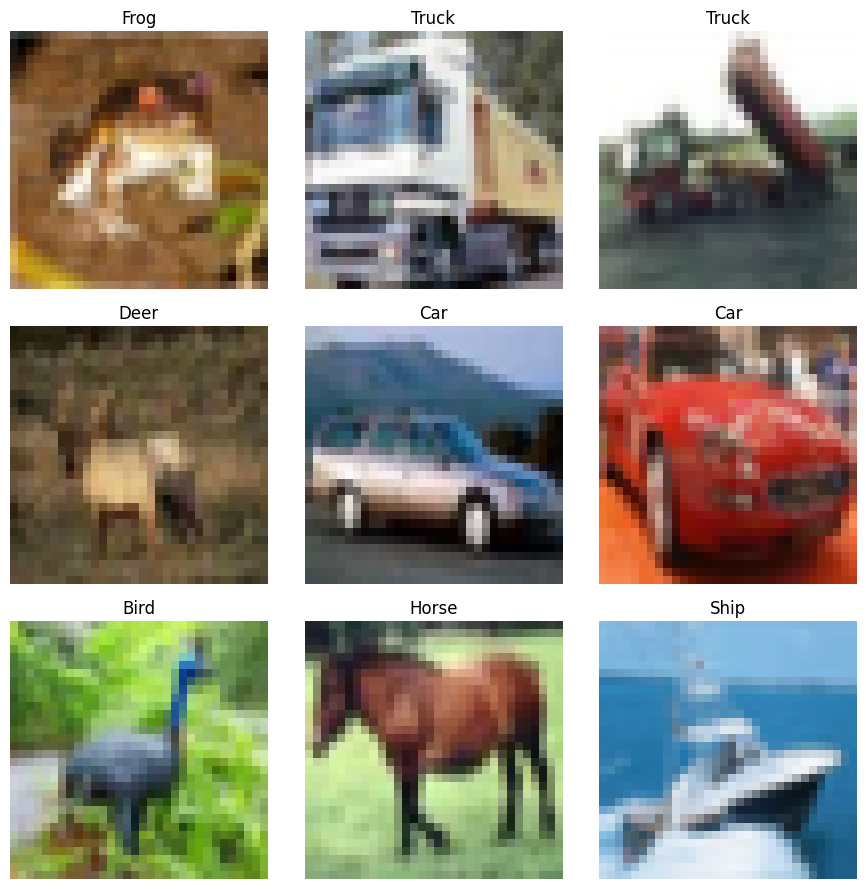

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,226 (8.37 MB)

 Trainable params: 2,193,226 (8.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 74s 230ms/step - accuracy: 0.4157 - loss: 1.6049 - val_accuracy: 0.5628 - val_loss: 1.2441
Epoch 2/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.5629 - loss: 1.2314 - val_accuracy: 0.5828 - val_loss: 1.1685
Epoch 3/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 218ms/step - accuracy: 0.6319 - loss: 1.0454 - val_accuracy: 0.6621 - val_loss: 0.9612
Epoch 4/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.6773 - loss: 0.9208 - val_accuracy: 0.6972 - val_loss: 0.8715
Epoch 5/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.7079 - loss: 0.8356 - val_accuracy: 0.7117 - val_loss: 0.8212
Epoch 6/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 218ms/step - accuracy: 0.7341 - loss: 0.7571 - val_accuracy: 0.7322 - val_loss: 0.7832
Epoch 7/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.7551 - loss: 0.7004 - val_accuracy: 0.7270 - val_loss: 0.7836
Epoch 8/12
313/313 ━━━━━━━━━━━━━━━━━━━━ 72s 230ms/step - accuracy: 0.7734 - loss: 0

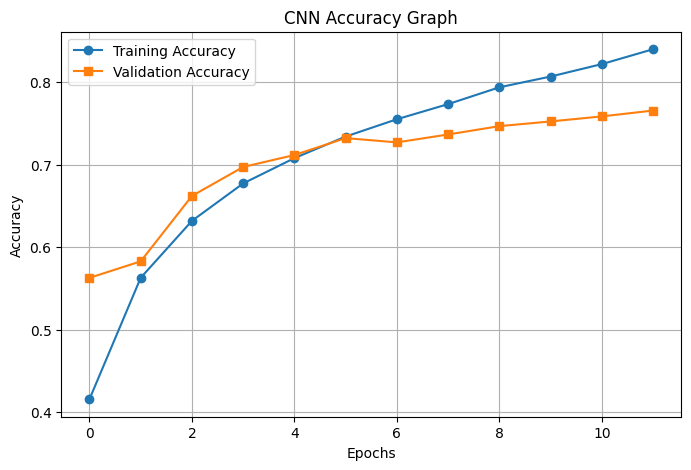

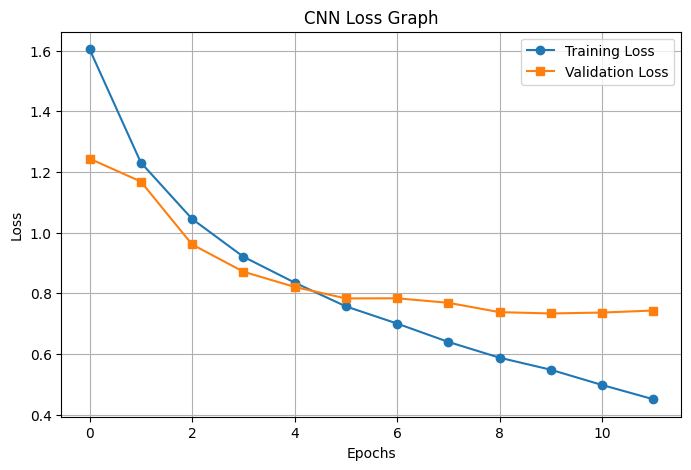

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, Sequential
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# Load CIFAR-10 Image Dataset
# ==============================

(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize Pixel Values
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# Label Names
labels = [
    'Airplane',
    'Car',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# ==============================
# Display Dataset Images
# ==============================

plt.figure(figsize=(9,9))

for index in range(9):
    plt.subplot(3,3,index + 1)
    plt.imshow(train_images[index])
    plt.title(labels[train_labels[index][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# ==============================
# Create CNN Model
# ==============================

cnn_model = Sequential()

# Convolution Layer 1
cnn_model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    padding='same',
    input_shape=(32,32,3)
))

cnn_model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
cnn_model.add(layers.Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
))

cnn_model.add(layers.MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
cnn_model.add(layers.Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu',
    padding='same'
))

cnn_model.add(layers.Dropout(0.3))

# Flatten Layer
cnn_model.add(layers.Flatten())

# Dense Layers
cnn_model.add(layers.Dense(
    256,
    activation='relu'
))

cnn_model.add(layers.Dropout(0.4))

# Output Layer
cnn_model.add(layers.Dense(
    10,
    activation='softmax'
))

# ==============================
# Model Information
# ==============================

cnn_model.summary()

# ==============================
# Compile CNN Model
# ==============================

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# Train the CNN
# ==============================

training_history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=12,
    batch_size=128,
    validation_split=0.2
)

# ==============================
# Evaluate Model Performance
# ==============================

loss, accuracy = cnn_model.evaluate(
    test_images,
    test_labels
)

print("\nFinal Test Accuracy :", accuracy)

# ==============================
# Accuracy Visualization
# ==============================

plt.figure(figsize=(8,5))

plt.plot(
    training_history.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    training_history.history['val_accuracy'],
    marker='s',
    label='Validation Accuracy'
)

plt.title("CNN Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ==============================
# Loss Visualization
# ==============================

plt.figure(figsize=(8,5))

plt.plot(
    training_history.history['loss'],
    marker='o',
    label='Training Loss'
)

plt.plot(
    training_history.history['val_loss'],
    marker='s',
    label='Validation Loss'
)

plt.title("CNN Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Conclusion: Successfully implemented an advanced CNN model using multiple convolution layers and dropout regularization for image classification on the CIFAR-10 dataset.